In [61]:
from dateutil.parser import parse
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import pickle
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_percentage_error
plt.rcParams.update({'figure.figsize': (10, 7), 'figure.dpi': 120})

In [ ]:
df_total = pd.read_csv('data/raw/sales.csv')
df_total.head()

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633


In [63]:
df_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    366 non-null    object 
 1   sales   366 non-null    float64
dtypes: float64(1), object(1)
memory usage: 5.8+ KB


<Axes: >

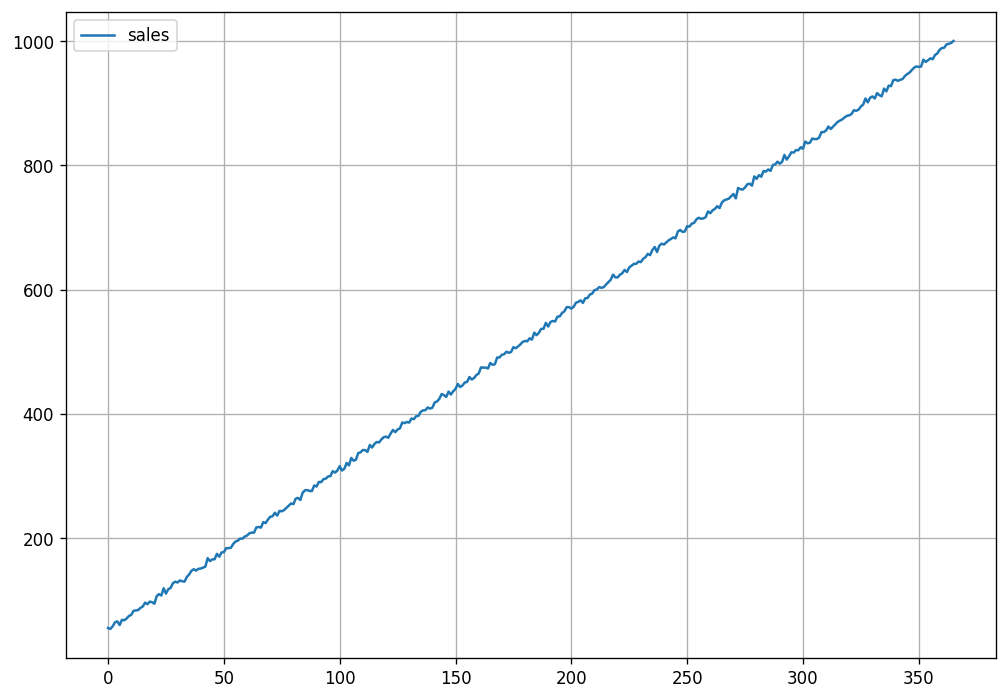

In [64]:
df_total.plot(grid=True)

In [65]:
df_total.shape


(366, 2)

In [66]:
df_total.describe()

,sales
count,366.000000
mean,524.963968
std,275.089698
min,53.803211
25%,290.186822
50%,520.699468
75%,763.289263
max,1000.482785


In [67]:
df_total.dtypes

date      object
sales    float64
dtype: object

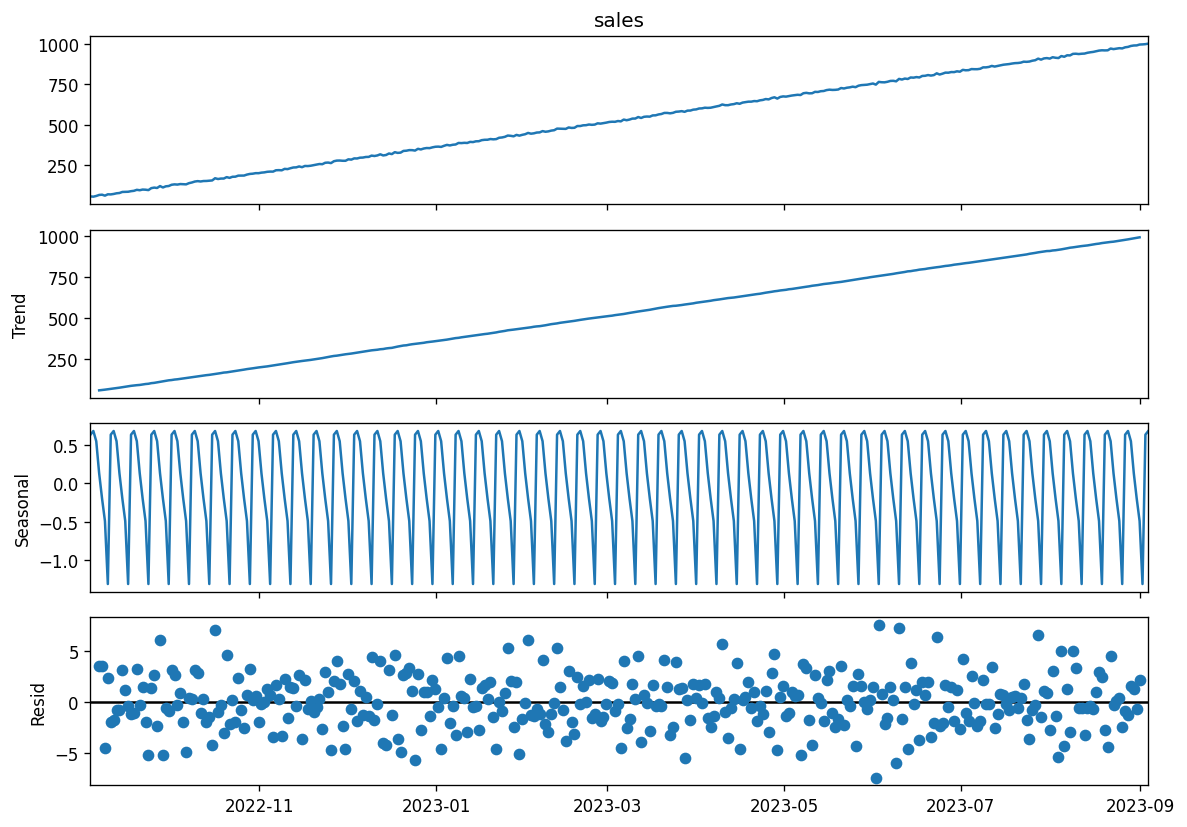

In [68]:


# Preparar los datos: La fecha debe ser el índice y tener una frecuencia
df_total['date'] = pd.to_datetime(df_total['date'])
df_total = df_total.set_index('date')
df_total = df_total.asfreq('D') # Definimos frecuencia diaria

# Descomponer (Modelo aditivo: Ventas = Tendencia + Estacionalidad + Residuo)
result = seasonal_decompose(df_total['sales'], model='additive')


result.plot()
plt.show()

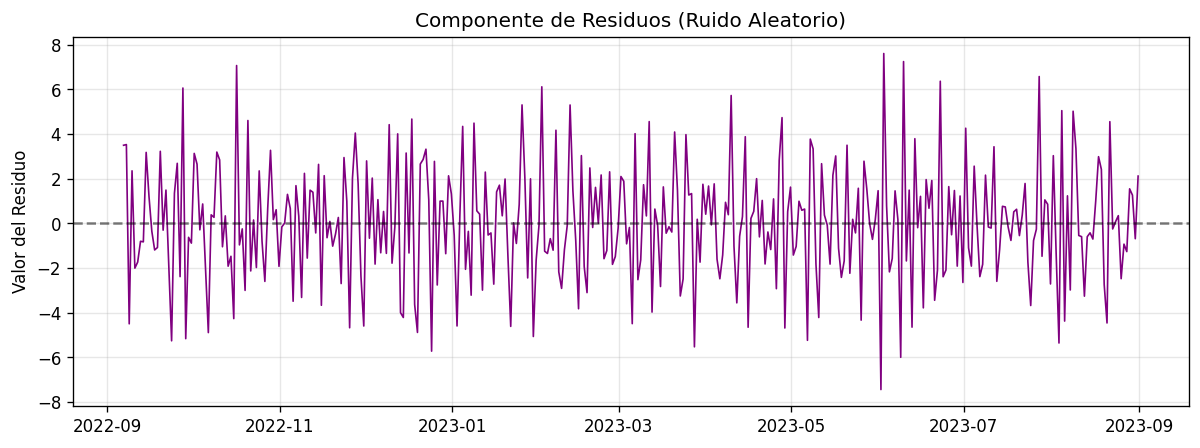

In [69]:


plt.figure(figsize=(12, 4))
plt.plot(result.resid, color='purple', linewidth=1)
plt.axhline(0, color='black', linestyle='--', alpha=0.5) # Línea de referencia en 0
plt.title('Componente de Residuos (Ruido Aleatorio)')
plt.ylabel('Valor del Residuo')
plt.grid(True, alpha=0.3)
plt.show()

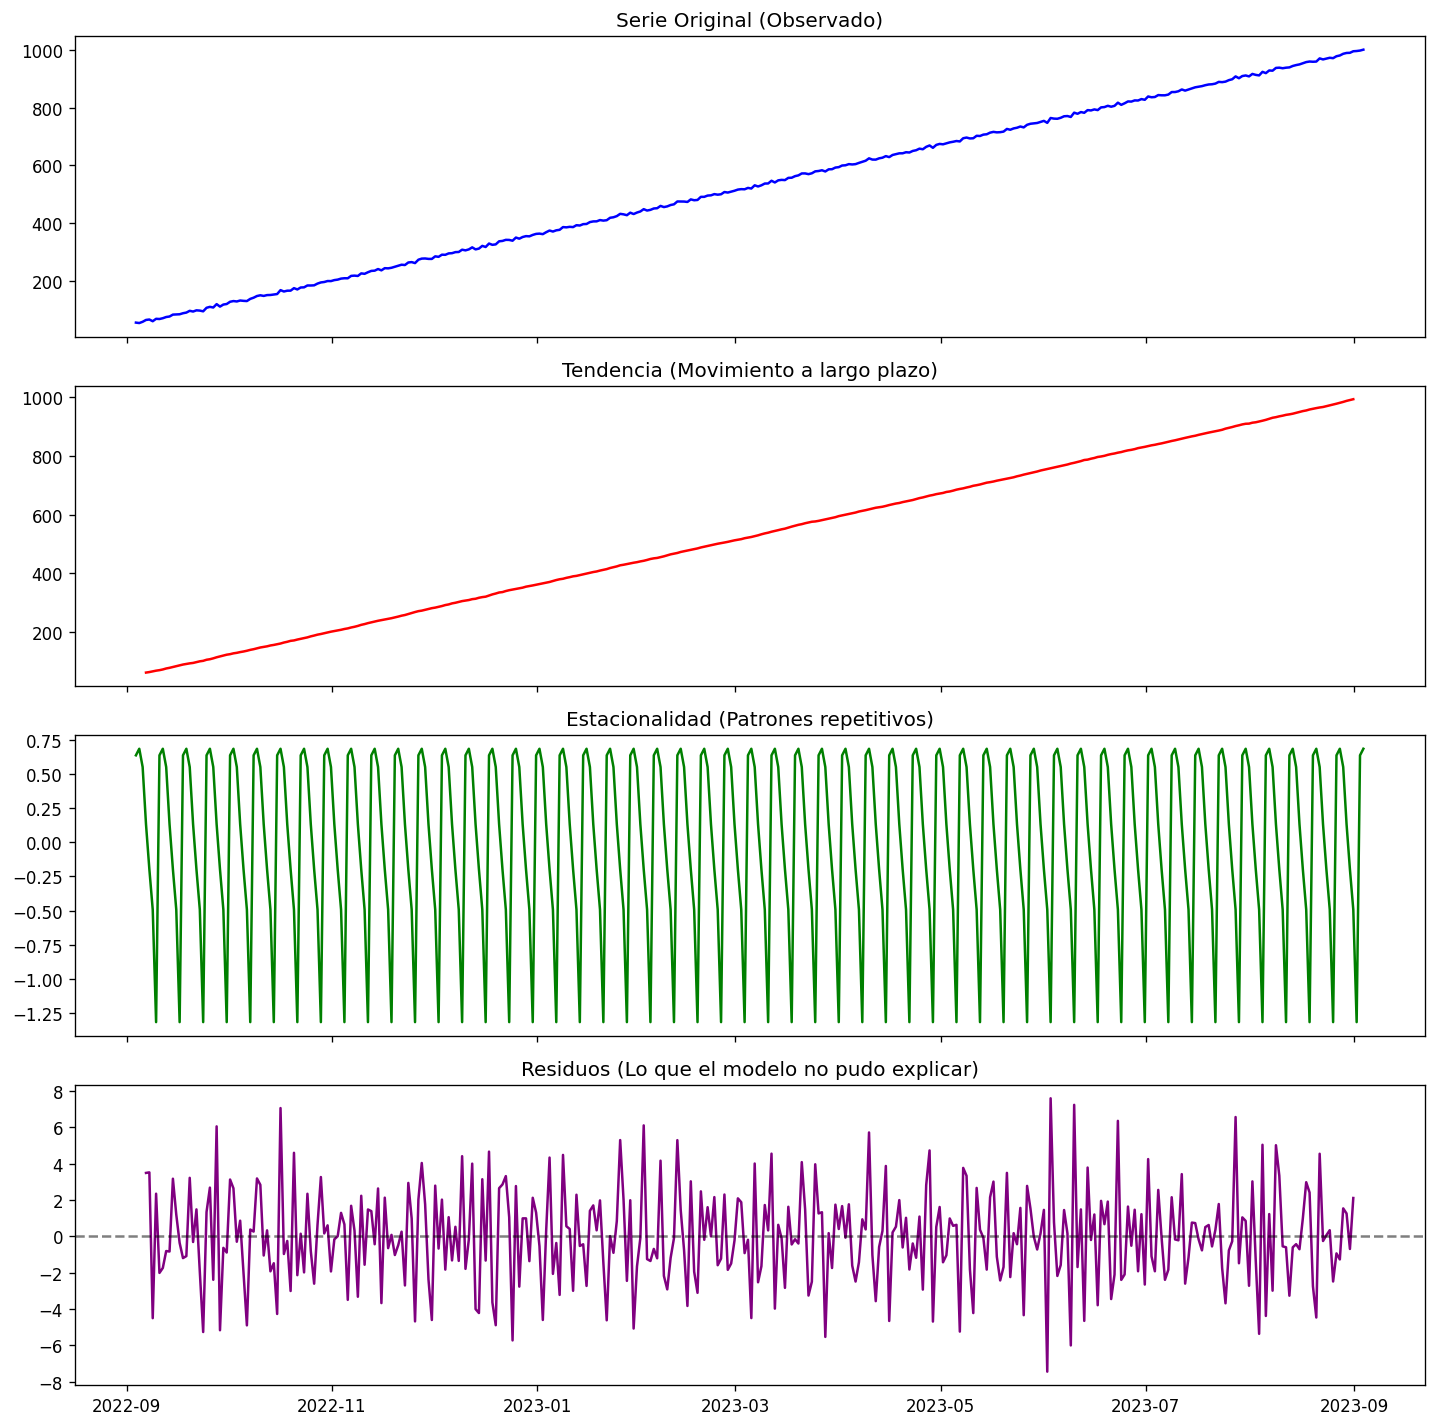

In [70]:
# Crear una figura con 4 subgráficos (eje X compartido)
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

# Observado
axes[0].plot(result.observed, color='blue')
axes[0].set_title('Serie Original (Observado)')

# Tendencia
axes[1].plot(result.trend, color='red')
axes[1].set_title('Tendencia (Movimiento a largo plazo)')

# Estacionalidad
axes[2].plot(result.seasonal, color='green')
axes[2].set_title('Estacionalidad (Patrones repetitivos)')

# Residuo (como línea continua)
axes[3].plot(result.resid, color='purple')
axes[3].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[3].set_title('Residuos (Lo que el modelo no pudo explicar)')

plt.tight_layout()
plt.show()

In [71]:
import pandas as pd



# Ejecutar el test de Dickey-Fuller Aumentado
# Pasamos la columna de ventas (sales)
resultado_adf = adfuller(df_total['sales'])

# Extraer y mostrar los resultados clave
print('--- Resultados del Test ADF ---')
print(f'Estadístico ADF: {resultado_adf[0]}')
print(f'p-valor: {resultado_adf[1]}')
print(f'Retrasos usados: {resultado_adf[2]}')
print(f'Número de observaciones: {resultado_adf[3]}')

# Lógica de interpretación automática
if resultado_adf[1] > 0.05:
    print("\nConclusión: El p-valor es mayor a 0.05.")
    print("La serie NO es estacionaria (tiene una raíz unitaria).")
else:
    print("\nConclusión: El p-valor es menor o igual a 0.05.")
    print("La serie ES estacionaria.")

--- Resultados del Test ADF ---
Estadístico ADF: 0.5454141937063646
p-valor: 0.986189981531106
Retrasos usados: 13
Número de observaciones: 352

Conclusión: El p-valor es mayor a 0.05.
La serie NO es estacionaria (tiene una raíz unitaria).


In [72]:


df_raw = pd.read_csv('sales.csv')

if 'date' in df_raw.columns:
    df_raw['date'] = pd.to_datetime(df_raw['date']).dt.normalize()
    df_raw = df_raw.set_index('date')

df = df_raw.asfreq('D')

# Dividir en Entrenamiento (Train) y Prueba (Test)
# Usamos el 90% para entrenar y el 10% final para medir la precisión
split_point = int(len(df) * 0.9)
train, test = df.iloc[:split_point], df.iloc[split_point:]

print(f"Entrenando con {len(train)} días. Probando con {len(test)} días.")

# Entrenar el modelo ARIMA
# Usamos el orden (5, 1, 1) que es robusto para estos datos
model = ARIMA(train['sales'], order=(5, 1, 1))
model_fit = model.fit()

# Realizar predicciones sobre el conjunto de TEST
predicciones = model_fit.forecast(steps=len(test))

# CALCULAR INDICADORES DE PRECISIÓN
mae = mean_absolute_error(test['sales'], predicciones)
rmse = np.sqrt(mean_squared_error(test['sales'], predicciones))
mape = mean_absolute_percentage_error(test['sales'], predicciones)
r2 = r2_score(test['sales'], predicciones)

# Mostrar Resultados
print("\n" + "="*30)
print(" INDICADORES DE PRECISIÓN")
print("="*30)
print(f"MAE (Error Medio Absoluto):      {mae:.4f}")
print(f"RMSE (Raíz del Error Cuadrático): {rmse:.4f}")
print(f"MAPE (Error Porcentual):         {mape:.4%}")
print(f"R² (Bondad de ajuste):           {r2:.4f}")
print("="*30)

# GUARDAR EL MODELO (Paso 5 de tu tarea)
with open('arima_model.pkl', 'wb') as f:
    pickle.dump(model_fit, f)

print("\nModelo guardado exitosamente como 'arima_model.pkl'")

Entrenando con 329 días. Probando con 37 días.

 INDICADORES DE PRECISIÓN
MAE (Error Medio Absoluto):      2.4223
RMSE (Raíz del Error Cuadrático): 3.0336
MAPE (Error Porcentual):         0.2567%
R² (Bondad de ajuste):           0.9884

Modelo guardado exitosamente como 'arima_model.pkl'


c:\Users\User\anaconda3\envs\demohealth\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [73]:

import os


nombre_carpeta = "modelos"
nombre_archivo = "arima_model.pkl"
ruta_completa = os.path.join(nombre_carpeta, nombre_archivo)


if not os.path.exists(nombre_carpeta):
    os.makedirs(nombre_carpeta)
    print(f"Carpeta '{nombre_carpeta}' creada.")


with open(ruta_completa, 'wb') as f:
    pickle.dump(model_fit, f)

print(f"Modelo almacenado exitosamente en: {ruta_completa}")

Modelo almacenado exitosamente en: modelos\arima_model.pkl


### Conclusiones

1. ¿Cuál es el tensor de la serie temporal?
El tensor de esta serie temporal es de rango 1 (un vector unidimensional). Técnicamente, tiene una forma o shape de (366,), lo que representa una secuencia lineal de 366 observaciones diarias correspondientes a una única variable dependiente (ventas).

2. ¿Cuál es la tendencia?
La serie presenta una tendencia alcista (ascendente) y lineal muy definida. Esto indica que el valor de las ventas se incrementa de manera constante a medida que transcurre el tiempo, sin mostrar cambios bruscos en la dirección del crecimiento a largo plazo.

3. ¿Es estacionaria?
No, la serie no es estacionaria. Para que una serie sea estacionaria, su media y su varianza deben permanecer constantes en el tiempo. En este caso, la fuerte tendencia alcista provoca que la media aumente continuamente. Además, estadísticamente se confirmó mediante la prueba de Dickey-Fuller Aumentada (ADF), la cual arrojó un p-valor de 0.98, lo que impide rechazar la hipótesis de no estacionariedad.

4. ¿Existe variabilidad o presencia de ruido?
Sí, la serie cuenta con ambos componentes:

Variabilidad: Se identifica una variabilidad estacional semanal. Esto significa que existen patrones que se repiten cada 7 días (por ejemplo, días específicos de la semana con ventas sistemáticamente más altas).

Ruido: Existe presencia de ruido aleatorio o residuos, que representan las variaciones impredecibles que no corresponden ni a la tendencia ni a la estacionalidad. Sin embargo, en esta serie el ruido es relativamente bajo, lo que indica un comportamiento muy estructurado y un buen ajuste para modelos predictivos